In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import random

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Dataset ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.RandomHorizontalFlip()
])

train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False)

# --- CNN Model ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1,16,3,stride=1,padding=1)
        self.pool  = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16,32,3,stride=1,padding=1)
        self.fc    = nn.Linear(32*7*7, 10)  # MNIST 28x28 -> after 2 pools -> 7x7

    def forward(self,x):
        x1 = self.conv1(x)
        x2 = torch.relu(x1)
        x3 = self.pool(x2)
        x4 = self.conv2(x3)
        x5 = torch.relu(x4)
        x6 = self.pool(x5)
        x_flat = x6.view(x6.size(0),-1)
        out = self.fc(x_flat)
        return out, [x1,x2,x3,x4,x5,x6]  # return feature maps for visualization

model = SimpleCNN().to(device)
print(model)

100%|██████████| 9.91M/9.91M [00:00<00:00, 44.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.02MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.15MB/s]

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=1568, out_features=10, bias=True)
)


In [2]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct, total = 0,0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs, _ = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()*images.size(0)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
    print(f"Epoch {epoch+1}: Loss={running_loss/total:.4f}, Acc={correct/total:.4f}")

Epoch 1: Loss=0.4614, Acc=0.8585
Epoch 2: Loss=0.1965, Acc=0.9354
Epoch 3: Loss=0.1504, Acc=0.9517
Epoch 4: Loss=0.1274, Acc=0.9593
Epoch 5: Loss=0.1105, Acc=0.9642


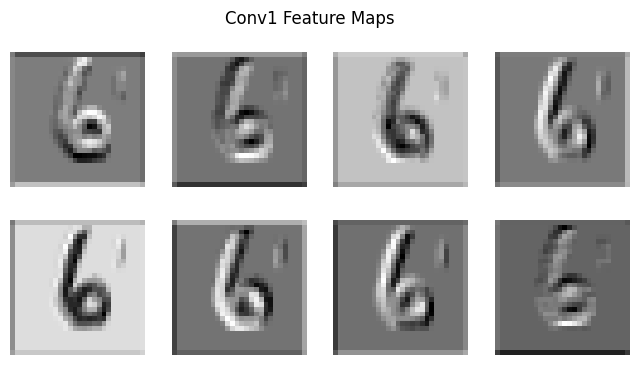

In [3]:
# pick random test image
model.eval()
img, label = random.choice(test_set)
img_input = img.unsqueeze(0).to(device)
_, features = model(img_input)

# visualize first conv layer feature maps
fmaps = features[0].detach().cpu()
plt.figure(figsize=(8,4))
for i in range(8):  # show first 8 filters
    plt.subplot(2,4,i+1)
    plt.imshow(fmaps[0,i].numpy(), cmap='gray')
    plt.axis('off')
plt.suptitle("Conv1 Feature Maps")
plt.show()

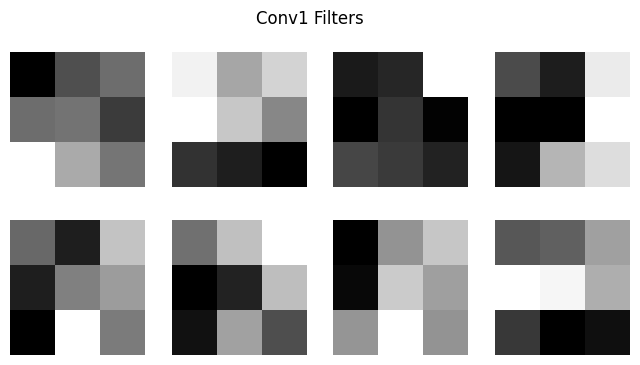

In [4]:
weights = model.conv1.weight.data.cpu()
plt.figure(figsize=(8,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(weights[i,0].numpy(), cmap='gray')
    plt.axis('off')
plt.suptitle("Conv1 Filters")
plt.show()

Test accuracy: 0.9646


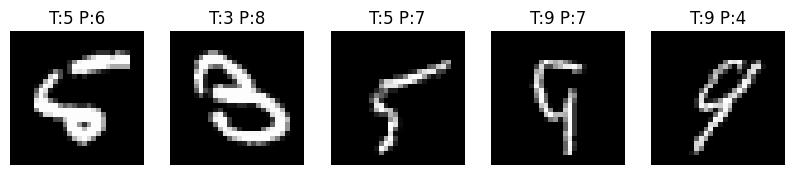

In [5]:
correct, total = 0,0
misclassified = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs, _ = model(images)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
        # collect misclassified
        for i in range(len(labels)):
            if preds[i] != labels[i]:
                misclassified.append((images[i].cpu(), labels[i].cpu(), preds[i].cpu()))

print("Test accuracy:", correct/total)

# show 5 misclassified
plt.figure(figsize=(10,2))
for i in range(5):
    img, true, pred = misclassified[i]
    img = img * 0.5 + 0.5  # unnormalize
    plt.subplot(1,5,i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"T:{true} P:{pred}")
    plt.axis('off')
plt.show()